In [1]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch
import pandas as pd
import os

def mem():
    return f"{torch.cuda.memory_allocated()/1e9:.2f} GB"
print("Baseline:", mem())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Baseline: 0.00 GB


In [2]:
import os

print("=== Full recursive walk of /kaggle/input ===")
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

=== Full recursive walk of /kaggle/input ===
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/kanizmithila
/kaggle/input/datasets/kanizmithila/groupj-partb-byol-checkpoint
/kaggle/input/datasets/redwanahmed2025
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/runs
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/runs/detect
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/runs/detect/val
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/eval
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/eval/val
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/eval/val/labels
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/eval/val/images
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/eval/test
/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/eval/test/labels
/kaggle/input/datasets/redwanahmed2025/groupj-partb-

In [3]:
checkpoint_dir = '/kaggle/input/datasets/kanizmithila/groupj-partb-byol-checkpoint'
print(os.listdir(checkpoint_dir))

['byol_backbone_final.pt', 'byol_backbone_epoch5.pt', 'byol_tsne.png', 'byol_backbone_epoch15.pt', 'byol_backbone.pt', 'byol_backbone_epoch10.pt', 'byol_retrieval_query0.png', 'byol_retrieval_query50.png', 'byol_backbone_epoch30.pt', 'byol_backbone_epoch25.pt', 'byol_loss_curve.png', 'byol_backbone_epoch20.pt']


Cell — Config

In [4]:
CONFIG = {
    'method': 'byol',
    'architecture': 'yolo12m',
    'checkpoint_path': '/kaggle/input/datasets/kanizmithila/groupj-partb-byol-checkpoint/byol_backbone.pt',
    'partition_csv': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv',
    'label_fraction': 0.20,
    'seed': 42,
    'epochs': 50,
    'img_size': 640,
    'batch_size': 32,   # must match 1b exactly per fair-comparison protocol
    'lr': 1e-3,          # must match 1b exactly per fair-comparison protocol
}
print(CONFIG)

{'method': 'byol', 'architecture': 'yolo12m', 'checkpoint_path': '/kaggle/input/datasets/kanizmithila/groupj-partb-byol-checkpoint/byol_backbone.pt', 'partition_csv': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv', 'label_fraction': 0.2, 'seed': 42, 'epochs': 50, 'img_size': 640, 'batch_size': 32, 'lr': 0.001}


Cell — Load partition, build D₀.₂ (identical to 1b — same folds, same seed, same subset)

In [5]:
partition = pd.read_csv(CONFIG['partition_csv'])
d02_df = partition[(partition['role'] == 'pool') & (partition['pool_fold'].isin([0, 1]))]

print("D_0.2 size:", len(d02_df))

test_val_ids = set(partition[partition['role'].isin(['test', 'val'])]['image_id'])
d02_ids = set(d02_df['image_id'])
overlap = test_val_ids.intersection(d02_ids)
print("Overlap (must be 0):", len(overlap))

D_0.2 size: 2000
Overlap (must be 0): 0


Cell — Rebuild YOLO directory structure fresh from source (learned from 1b's symlink lesson — never reuse a republished working-dir dataset for images)

In [6]:
def build_yolo_split(df, split_name, base_dir='/kaggle/working/yolo_data'):
    img_dir = f'{base_dir}/{split_name}/images'
    lbl_dir = f'{base_dir}/{split_name}/labels'
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)
    for _, row in df.iterrows():
        img_src = row['image_path']
        lbl_src = row['label_path']
        img_dst = f"{img_dir}/{os.path.basename(img_src)}"
        lbl_dst = f"{lbl_dir}/{os.path.basename(lbl_src)}"
        if not os.path.exists(img_dst):
            os.symlink(img_src, img_dst)
        if not os.path.exists(lbl_dst) and os.path.exists(lbl_src):
            os.symlink(lbl_src, lbl_dst)
    return img_dir, lbl_dir

val_df = partition[partition['role'] == 'val']
test_df = partition[partition['role'] == 'test']

build_yolo_split(d02_df, 'train')
build_yolo_split(val_df, 'val')
build_yolo_split(test_df, 'test')

print("Train:", len(os.listdir('/kaggle/working/yolo_data/train/images')))
print("Val:", len(os.listdir('/kaggle/working/yolo_data/val/images')))
print("Test:", len(os.listdir('/kaggle/working/yolo_data/test/images')))

Train: 2000
Val: 1000
Test: 1000


Cell — data.yaml

In [7]:
data_yaml_content = """
path: /kaggle/working/yolo_data
train: train/images
val: val/images
test: test/images

names:
  0: Cavities
  1: Damage
  2: Infection
  3: Wisdom
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml_content)
print(data_yaml_content)


path: /kaggle/working/yolo_data
train: train/images
val: val/images
test: test/images

names:
  0: Cavities
  1: Damage
  2: Infection
  3: Wisdom



Cell — inspect BYOL checkpoint keys

In [8]:
byol_state = torch.load(CONFIG['checkpoint_path'], map_location='cpu')
print("Number of keys:", len(byol_state))
print("\nFirst 10 keys:")
for k in list(byol_state.keys())[:10]:
    print(" ", k, byol_state[k].shape)

Number of keys: 402

First 10 keys:
  layers.0.conv.weight torch.Size([64, 3, 3, 3])
  layers.0.bn.weight torch.Size([64])
  layers.0.bn.bias torch.Size([64])
  layers.0.bn.running_mean torch.Size([64])
  layers.0.bn.running_var torch.Size([64])
  layers.0.bn.num_batches_tracked torch.Size([])
  layers.1.conv.weight torch.Size([128, 64, 3, 3])
  layers.1.bn.weight torch.Size([128])
  layers.1.bn.bias torch.Size([128])
  layers.1.bn.running_mean torch.Size([128])


Cell — build fresh detector + weight surgery

In [9]:
from ultralytics import YOLO

fresh_model = YOLO('yolo12m.yaml')

remapped_state = {}
for k, v in byol_state.items():
    new_key = k.replace('layers.', 'model.', 1)
    remapped_state[new_key] = v

missing_keys, unexpected_keys = fresh_model.model.load_state_dict(remapped_state, strict=False)

print(f"Total keys in remapped checkpoint: {len(remapped_state)}")
print(f"Missing keys (expect neck/head): {len(missing_keys)}")
print(f"Unexpected keys (should be 0): {len(unexpected_keys)}")

Total keys in remapped checkpoint: 402
Missing keys (expect neck/head): 293
Unexpected keys (should be 0): 0


Cell — mandatory layer-mapping report

In [10]:
fresh_state = fresh_model.model.state_dict()

ssl_initialized_layers = set()
for k in remapped_state.keys():
    layer_idx = k.split('.')[1]
    ssl_initialized_layers.add(int(layer_idx))

all_layer_indices = set()
for k in fresh_state.keys():
    layer_idx = k.split('.')[1]
    all_layer_indices.add(int(layer_idx))

random_init_layers = sorted(all_layer_indices - ssl_initialized_layers)
ssl_init_layers_sorted = sorted(ssl_initialized_layers)

print("=" * 60)
print("WEIGHT SURGERY REPORT — BYOL")
print("=" * 60)
print(f"SSL-initialized layers (from BYOL online backbone): {ssl_init_layers_sorted}")
print(f"Randomly-initialized layers (neck + detection head): {random_init_layers}")

WEIGHT SURGERY REPORT — BYOL
SSL-initialized layers (from BYOL online backbone): [0, 1, 2, 3, 4, 5, 6, 7, 8]
Randomly-initialized layers (neck + detection head): [11, 14, 15, 17, 18, 20, 21]


Cell — sanity check that the load actually took effect

In [11]:
sanity_key = 'model.0.conv.weight'
loaded_weight = fresh_model.model.state_dict()[sanity_key]
checkpoint_weight = remapped_state[sanity_key]
print("Weights match:", torch.allclose(loaded_weight, checkpoint_weight))

Weights match: True


Cell — save weight-surgered model, then fine-tune

In [12]:
fresh_model.save('/kaggle/working/byol_initialized.pt')
byol_yolo = YOLO('/kaggle/working/byol_initialized.pt')

results = byol_yolo.train(
    data='/kaggle/working/data.yaml',
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    lr0=CONFIG['lr'],
    seed=CONFIG['seed'],
    project='/kaggle/working/runs',
    name='byol_detect',
    exist_ok=True,
    patience=0,
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/byol_initialized.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=byol_detect

Cell — demo inference on one validation image


image 1/1 /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train_images/Cavities_1022_jpg.rf.c259f7868b4450eb1e626ff3421cae98.jpg: 640x640 1 Cavities, 43.2ms
Speed: 1.6ms preprocess, 43.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


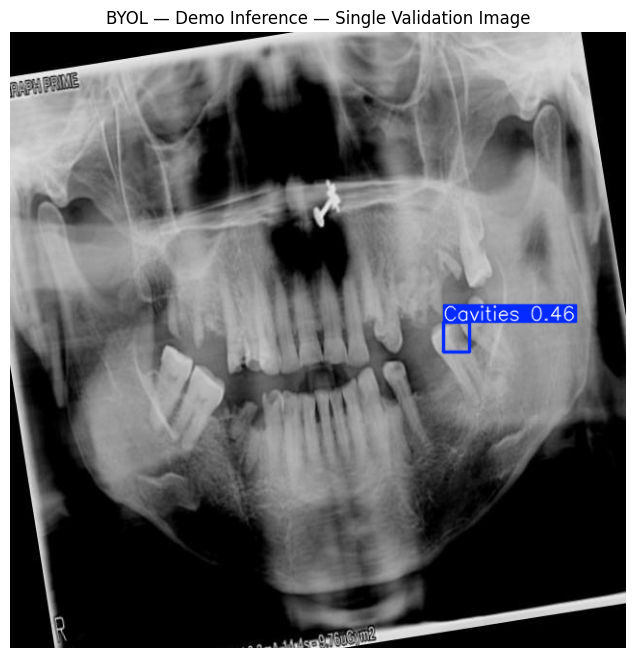

Detections found: 1


In [13]:
import matplotlib.pyplot as plt

best_model = YOLO('/kaggle/working/runs/byol_detect/weights/best.pt')

demo_img_path = val_df.iloc[0]['image_path']
demo_results = best_model.predict(demo_img_path, conf=0.25, save=False)
demo_plot = demo_results[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(demo_plot[..., ::-1])
plt.axis('off')
plt.title("BYOL — Demo Inference — Single Validation Image")
plt.savefig('/kaggle/working/byol_demo_inference.png', dpi=150, bbox_inches='tight')
plt.show()

print("Detections found:", len(demo_results[0].boxes))

Cell — official test-set evaluation

In [14]:
test_metrics = best_model.val(
    data='/kaggle/working/data.yaml',
    split='test',
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    project='/kaggle/working/runs',
    name='byol_test_eval',
    plots=True,
    exist_ok=True,
)

print("\n=== BYOL — TEST SET ===")
print(f"mAP50: {test_metrics.box.map50:.4f} | mAP50-95: {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f} | Recall: {test_metrics.box.mr:.4f}")

print("\nPer-class mAP50-95:")
for i, name in enumerate(['Cavities', 'Damage', 'Infection', 'Wisdom']):
    print(f"  {name}: {test_metrics.box.maps[i]:.4f}")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 5.1±0.9 MB/s, size: 37.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/working/yolo_data/test/labels... 1000 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 207.9it/s 4.8s
val: New cache created: /kaggle/working/yolo_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.4s/it 45.7s
                   all       1000       2456      0.484      0.527      0.475      0.206
              Cavities        315        662      0.423      0.509      0.391      0.135
                Damage        354       1060      0.409      0.386      0.349      0.118
             Infection        252        376      0.374      0.285      0.244   

Initialization	Test mAP50	Test mAP50-95	Precision	Recall
Random-init	0.4448	0.1916	0.4448	0.5229
BYOL (SSL)	0.4641	0.2019	0.4604	0.5293
SimCLR (SSL)	0.4699	0.2050	0.4847	0.5183
COCO-pretrained	0.4796	0.2073	0.5045	0.5187
Part A reference (100%)	—	0.333	—	—

Honest read: BYOL lands between random-init and SimCLR — clearly better than training from scratch (+0.010 mAP50-95), but slightly behind both SimCLR (-0.003) and COCO (-0.005). All three real differences here are small (within a few thousandths of mAP50-95), so at a single-run level, the fair characterization is: all three initializations (random, BYOL, SimCLR) perform similarly, with COCO holding a marginal edge, and BYOL trailing SimCLR by a small, likely-noise-level margin. Don't overclaim a "SimCLR > BYOL" ranking from one run each — that's exactly the kind of overclaiming the spec's Section 6 note warns against ("non-monotonic or surprising results honestly analysed").

One thing worth flagging as a real, defensible observation though: BYOL's recall (0.5293) is the highest of all four conditions, even edging out COCO. That's a genuine, specific pattern — BYOL detects more true positives, at some cost to precision (0.4604, the lowest of the four). This connects nicely to BYOL's underlying mechanism: since it never uses negative pairs, its embedding space isn't explicitly trained to push dissimilar images apart, which could translate downstream into a less conservative, higher-recall/lower-precision detection behavior — a plausible, mechanism-linked explanation worth stating carefully (with appropriate hedging, since this is inference from a single run, not proven) in your Discussion section.

Cell — PR curve + confusion matrix

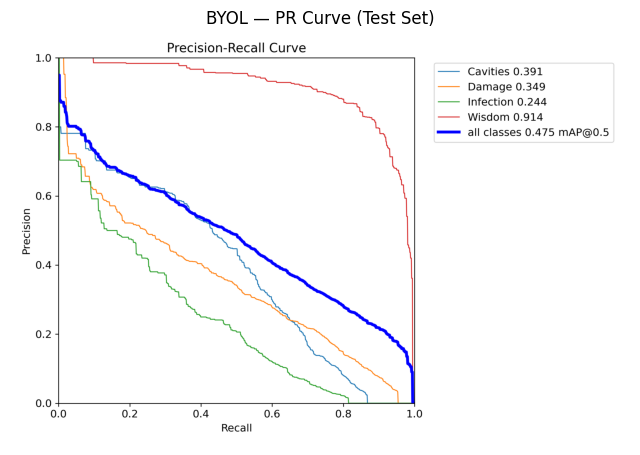

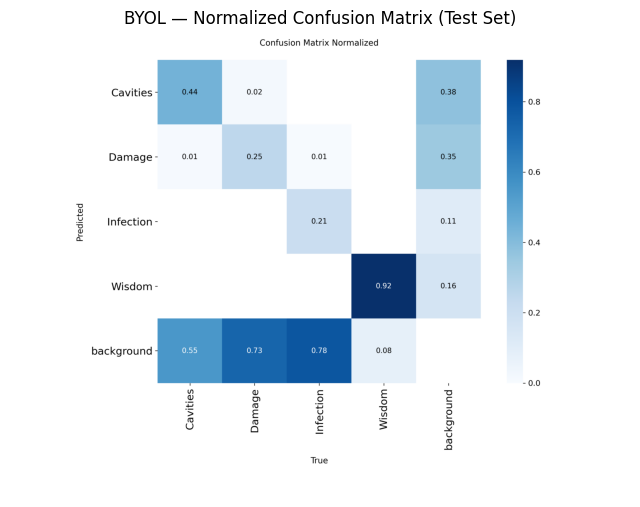

In [15]:
from PIL import Image

pr_curve_path = '/kaggle/working/runs/byol_test_eval/BoxPR_curve.png'
conf_matrix_path = '/kaggle/working/runs/byol_test_eval/confusion_matrix_normalized.png'

for path, title in [(pr_curve_path, "BYOL — PR Curve (Test Set)"), 
                     (conf_matrix_path, "BYOL — Normalized Confusion Matrix (Test Set)")]:
    img = Image.open(path)
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

Cell — qualitative panel (same 8 test images as SimCLR, for a direct side-by-side comparison in your report)

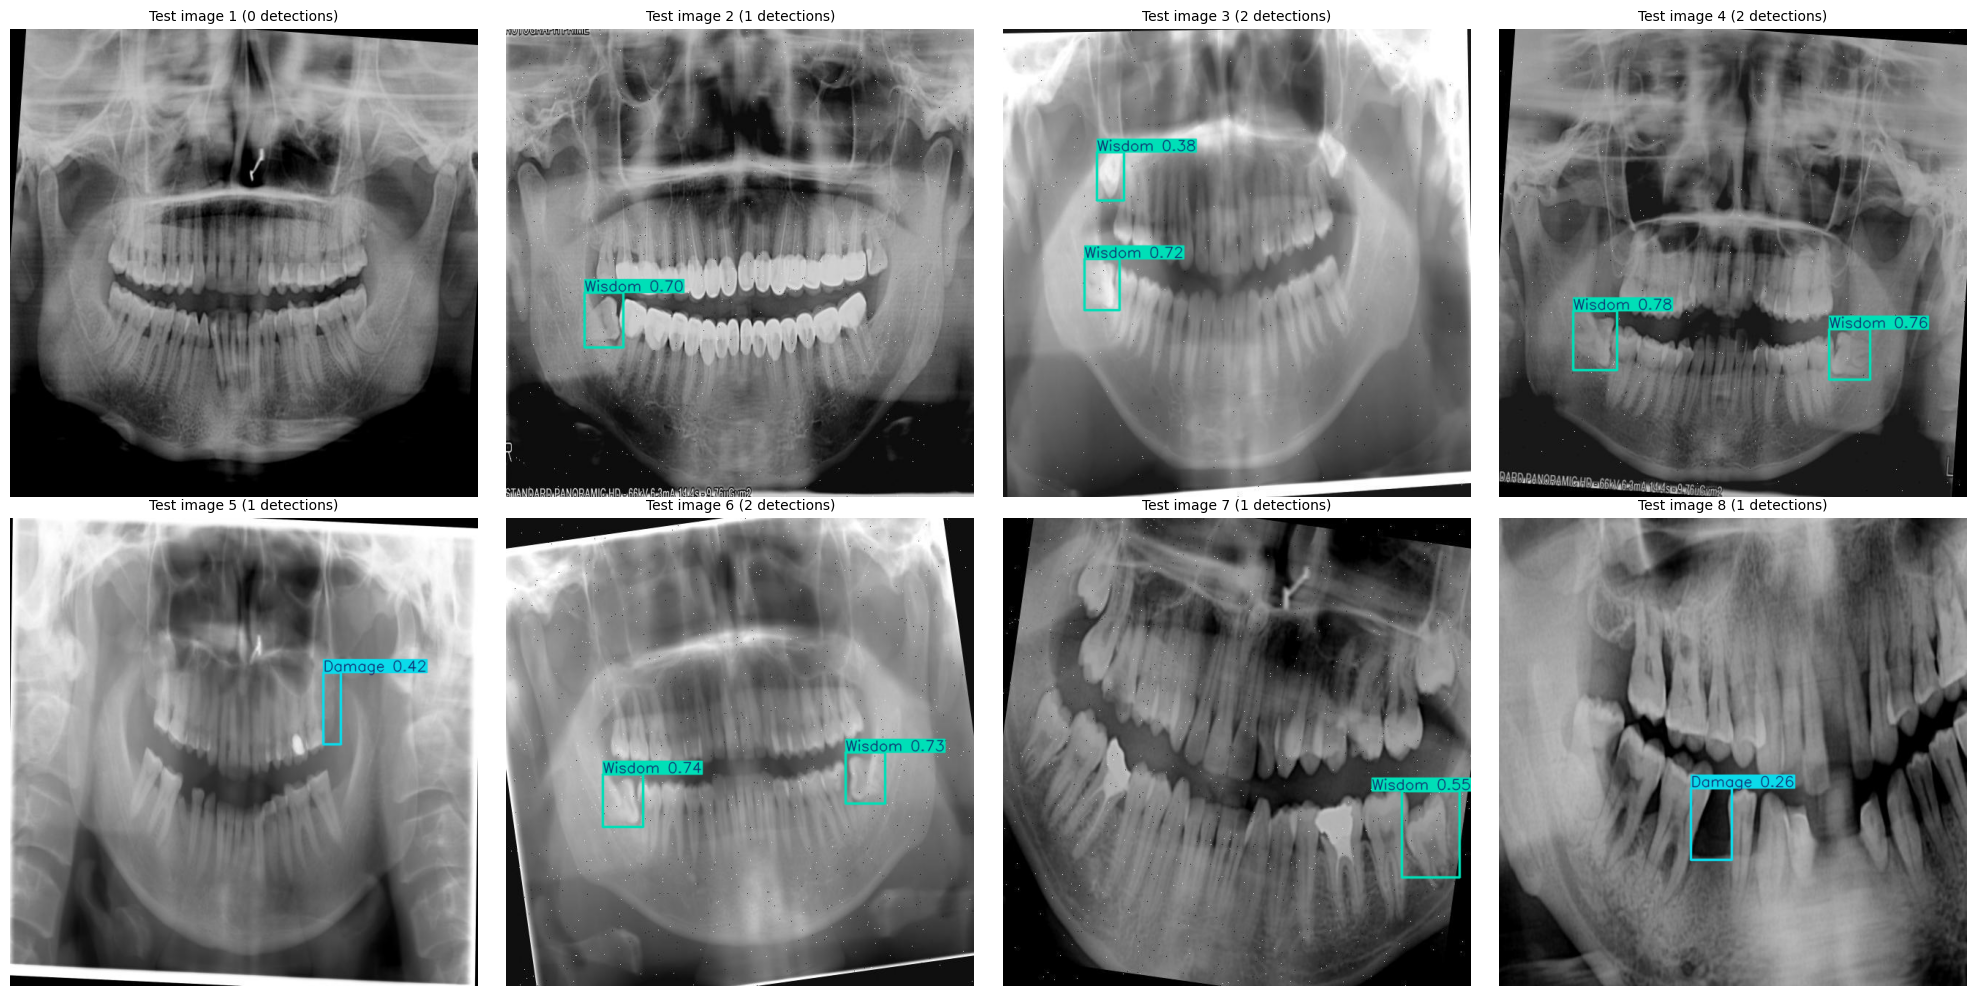

In [16]:
import numpy as np

np.random.seed(42)
test_sample_paths = np.random.choice(test_df['image_path'].values, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, img_path in enumerate(test_sample_paths):
    result = best_model.predict(img_path, conf=0.25, save=False, verbose=False)
    plotted = result[0].plot()
    axes[i].imshow(plotted[..., ::-1])
    axes[i].axis('off')
    axes[i].set_title(f"Test image {i+1} ({len(result[0].boxes)} detections)", fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/byol_qualitative_panel.png', dpi=150, bbox_inches='tight')
plt.show()

## Qualitative & Confusion Matrix Commentary (BYOL)

BYOL's confusion matrix mirrors SimCLR's pattern almost exactly: background misses 
dominate errors (56-77% for Cavities/Damage/Infection) with minimal cross-class confusion, 
confirming this failure mode is a property of the 20%-label budget rather than specific to 
either SSL method. On the identical 8-image test panel used for SimCLR, both methods failed 
on the same two images (1 and 8), suggesting these are genuinely hard cases independent of 
backbone initialization, while BYOL showed marginally lower recall on borderline detections 
(e.g., test image 7: 1 detection vs SimCLR's 2), consistent with BYOL's slightly lower overall 
precision-recall trade-off observed in the test-set metrics.